<a href="https://colab.research.google.com/github/shravyataluka-codes/neurons-to-networks/blob/main/ps_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# Task 1: Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
# Task 2: Load dataset
df = pd.read_csv("/content/weatherHistory.csv")
print("First 3 rows:")
print(df.head(3))
print("\nLast 3 rows:")
print(df.tail(3))


First 3 rows:
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13   
1                   259.0          15.8263         0.0               1015.63   
2                   204.0          14.9569         0.0               1015.94   

                       Daily Summary  
0  Partly cloudy throughout the day.  
1  Partly cloudy througho

In [22]:
# Task 3: Summary statistics and missing values

print("Summary Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Columns:")
print(df.columns)

Summary Statistics:


,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000



Missing Values:
Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

Dataset Columns:
Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')


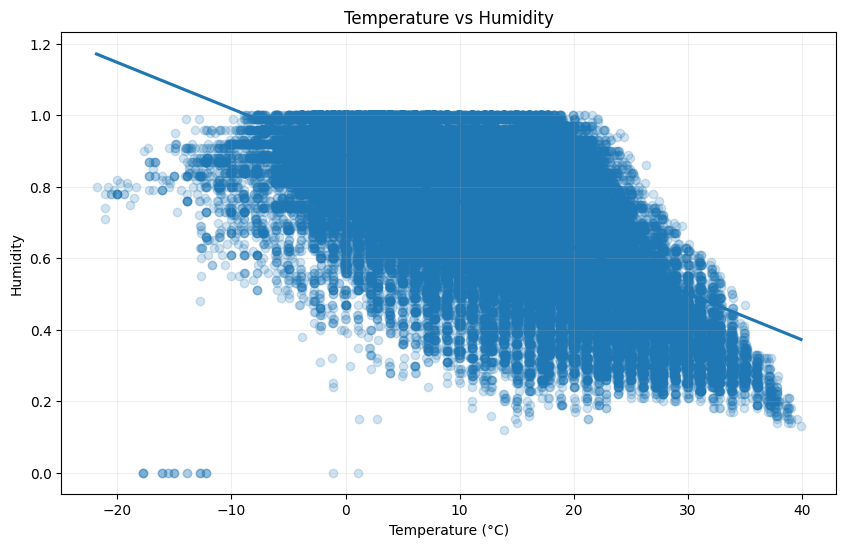

In [23]:
## Task 4: Scatter plot with regression trendline

plt.figure(figsize=(10, 6))

sns.regplot(
    x="Temperature (C)",
    y="Humidity",
    data=df,
    scatter_kws={"alpha": 0.2},
    line_kws={}
)

plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity")
plt.grid(True, alpha=0.2)
plt.show()

In [24]:
print("Observation:")
print("The scatter plot shows a generally negative relationship between")
print("temperature and humidity: as temperature increases, humidity")
print("tends to decrease. However, the points are widely scattered,")
print("indicating that temperature alone does not completely explain humidity.")

Observation:
The scatter plot shows a generally negative relationship between
temperature and humidity: as temperature increases, humidity
tends to decrease. However, the points are widely scattered,
indicating that temperature alone does not completely explain humidity.


In [25]:
# Task 5: Simple Linear Regression

X = df[["Temperature (C)"]]
y = df["Humidity"]

# 60:40 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

# Create and train the model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred_train = lin_reg.predict(X_train)
y_pred_test = lin_reg.predict(X_test)

# Evaluation metrics
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_pred_train)

test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

print("Simple Linear Regression Results")
print("---------------------------------")

print("Train MSE :", train_mse)
print("Train RMSE:", train_rmse)
print("Train R²  :", train_r2)

print("\nTest MSE  :", test_mse)
print("Test RMSE :", test_rmse)
print("Test R²   :", test_r2)

Simple Linear Regression Results
---------------------------------
Train MSE : 0.022857758982701395
Train RMSE: 0.151187826833715
Train R²  : 0.4024992367588738

Test MSE  : 0.02305202084978087
Test RMSE : 0.15182891967534007
Test R²   : 0.39558655784914665


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


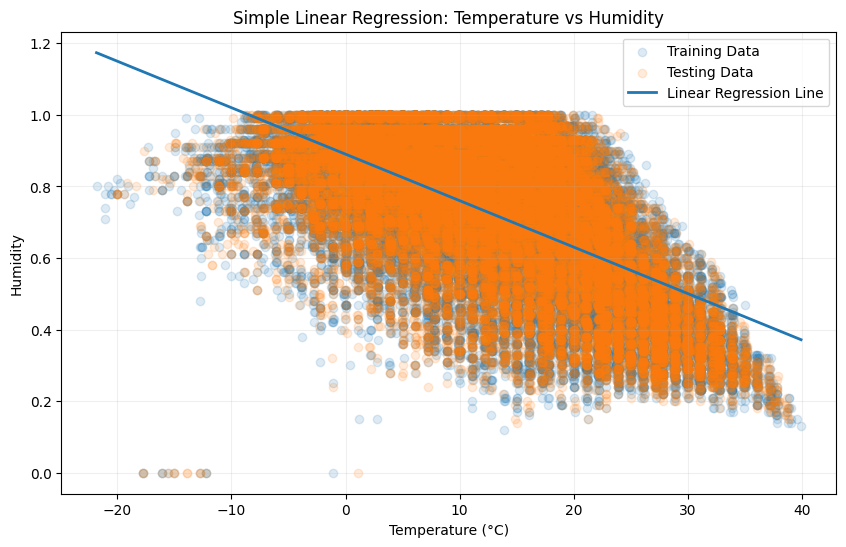

In [26]:
# Regression line visualization for training and testing data

plt.figure(figsize=(10, 6))

# Training data
plt.scatter(
    X_train["Temperature (C)"],
    y_train,
    alpha=0.15,
    label="Training Data"
)

# Testing data
plt.scatter(
    X_test["Temperature (C)"],
    y_test,
    alpha=0.15,
    label="Testing Data"
)

# Sort values so the regression line is plotted smoothly
x_line = np.linspace(
    X["Temperature (C)"].min(),
    X["Temperature (C)"].max(),
    200
).reshape(-1, 1)

y_line = lin_reg.predict(x_line)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Linear Regression Line"
)

plt.title("Simple Linear Regression: Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [27]:
# Task 6: Multiple Linear Regression

X_multi = df[
    ["Temperature (C)", "Wind Speed (km/h)"]
]

y = df["Humidity"]

# Same 60:40 split
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi,
    y,
    test_size=0.4,
    random_state=42
)

# Create and train model
multi_reg = LinearRegression()
multi_reg.fit(X_multi_train, y_multi_train)

# Predictions
y_pred_multi = multi_reg.predict(X_multi_test)

# Evaluation
multi_mse = mean_squared_error(y_multi_test, y_pred_multi)
multi_rmse = np.sqrt(multi_mse)
multi_r2 = r2_score(y_multi_test, y_pred_multi)

print("Multiple Linear Regression Results")
print("-----------------------------------")
print("MSE :", multi_mse)
print("RMSE:", multi_rmse)
print("R²  :", multi_r2)

Multiple Linear Regression Results
-----------------------------------
MSE : 0.02116986054014174
RMSE: 0.1454986616438163
R²  : 0.4449359402239903


In [28]:
# Compare Simple and Multiple Linear Regression

comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MSE": [
        test_mse,
        multi_mse
    ],
    "RMSE": [
        test_rmse,
        multi_rmse
    ],
    "R²": [
        test_r2,
        multi_r2
    ]
})

display(comparison)

,Model,MSE,RMSE,R²
0,Simple Linear Regression,0.023052,0.151829,0.395587
1,Multiple Linear Regression,0.021170,0.145499,0.444936


In [29]:
print("Comparison:")
print(
    f"Simple Regression Test R²: {test_r2:.4f}"
)

print(
    f"Multiple Regression Test R²: {multi_r2:.4f}"
)

if multi_r2 > test_r2:
    print(
        "\nAdding Wind Speed improved the model's test-set R²."
    )
else:
    print(
        "\nAdding Wind Speed did not improve the model's test-set R²."
    )

Comparison:
Simple Regression Test R²: 0.3956
Multiple Regression Test R²: 0.4449

Adding Wind Speed improved the model's test-set R².


In [30]:
# Task 7: Polynomial Regression

X_poly_base = df[["Temperature (C)"]]
y = df["Humidity"]

# Use the same 60:40 split
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly_base,
    y,
    test_size=0.4,
    random_state=42
)

poly_results = []

for degree in range(2, 6):

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_poly_train)
    X_test_poly = poly.transform(X_poly_test)

    # Train linear regression on polynomial features
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_poly_train)

    # Predictions
    y_pred_poly = poly_reg.predict(X_test_poly)

    # Metrics
    mse = mean_squared_error(y_poly_test, y_pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_poly_test, y_pred_poly)

    poly_results.append({
        "Degree": degree,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    })

# Display results
poly_results_df = pd.DataFrame(poly_results)

display(poly_results_df)

,Degree,MSE,RMSE,R²
0,2,0.020398,0.142822,0.465172
1,3,0.020397,0.142817,0.465208
2,4,0.020382,0.142766,0.465593
3,5,0.020252,0.142308,0.469010


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


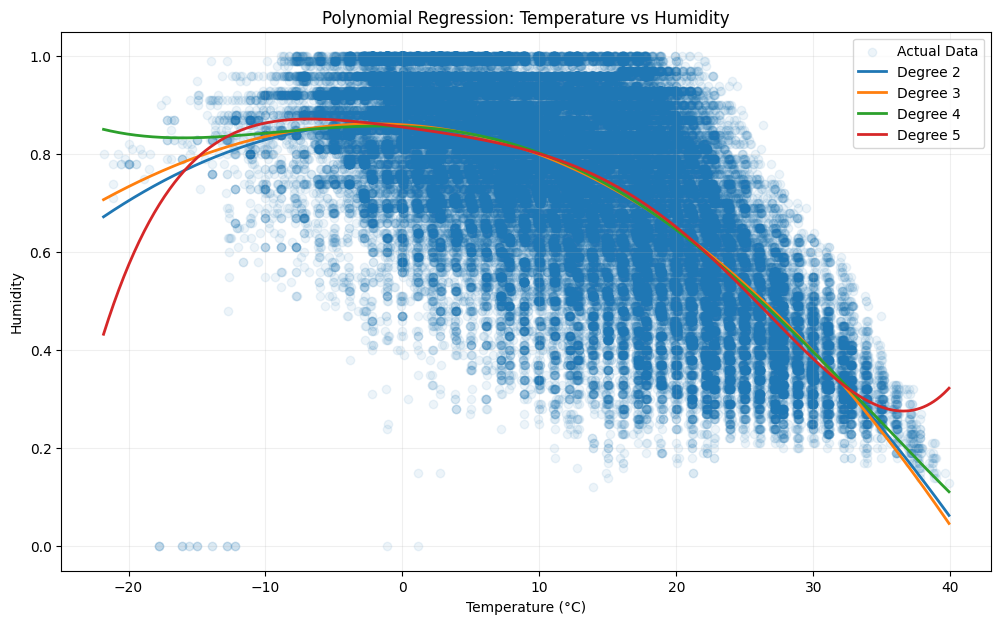

In [31]:
# Plot polynomial curves for degrees 2 to 5

plt.figure(figsize=(12, 7))

# Actual data points
plt.scatter(
    X_poly_base["Temperature (C)"],
    y,
    alpha=0.08,
    label="Actual Data"
)

# Smooth temperature values for plotting curves
X_curve = np.linspace(
    X_poly_base["Temperature (C)"].min(),
    X_poly_base["Temperature (C)"].max(),
    500
).reshape(-1, 1)

for degree in range(2, 6):

    poly = PolynomialFeatures(degree=degree)

    # Fit transformation on training data
    X_train_poly = poly.fit_transform(X_poly_train)

    # Train model
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_poly_train)

    # Transform curve data using the same polynomial transformer
    X_curve_poly = poly.transform(X_curve)

    # Predict
    y_curve = poly_reg.predict(X_curve_poly)

    # Plot
    plt.plot(
        X_curve,
        y_curve,
        linewidth=2,
        label=f"Degree {degree}"
    )

plt.title("Polynomial Regression: Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [32]:
# Final comparison of all models

final_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression - Degree 2",
        "Polynomial Regression - Degree 3",
        "Polynomial Regression - Degree 4",
        "Polynomial Regression - Degree 5"
    ],
    "MSE": [
        test_mse,
        multi_mse,
        poly_results_df.loc[poly_results_df["Degree"] == 2, "MSE"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 3, "MSE"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 4, "MSE"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 5, "MSE"].iloc[0]
    ],
    "RMSE": [
        test_rmse,
        multi_rmse,
        poly_results_df.loc[poly_results_df["Degree"] == 2, "RMSE"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 3, "RMSE"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 4, "RMSE"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 5, "RMSE"].iloc[0]
    ],
    "R²": [
        test_r2,
        multi_r2,
        poly_results_df.loc[poly_results_df["Degree"] == 2, "R²"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 3, "R²"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 4, "R²"].iloc[0],
        poly_results_df.loc[poly_results_df["Degree"] == 5, "R²"].iloc[0]
    ]
})

display(final_comparison)

,Model,MSE,RMSE,R²
0,Simple Linear Regression,0.023052,0.151829,0.395587
1,Multiple Linear Regression,0.021170,0.145499,0.444936
2,Polynomial Regression - Degree 2,0.020398,0.142822,0.465172
3,Polynomial Regression - Degree 3,0.020397,0.142817,0.465208
4,Polynomial Regression - Degree 4,0.020382,0.142766,0.465593
5,Polynomial Regression - Degree 5,0.020252,0.142308,0.469010


In [33]:
# Final conclusion

best_model = final_comparison.loc[
    final_comparison["R²"].idxmax()
]

print("Final Conclusion")
print("-----------------")
print(
    f"The best test-set R² among the models tested was obtained by "
    f"{best_model['Model']} with R² = {best_model['R²']:.4f}."
)

print(
    "\nSimple Linear Regression uses Temperature as the only predictor."
)

print(
    "Multiple Linear Regression adds Wind Speed as an additional predictor."
)

print(
    "Polynomial Regression models the nonlinear relationship between "
    "Temperature and Humidity."
)

print(
    "\nThe model comparison should be based on test-set performance, "
    "not training performance."
)

Final Conclusion
-----------------
The best test-set R² among the models tested was obtained by Polynomial Regression - Degree 5 with R² = 0.4690.

Simple Linear Regression uses Temperature as the only predictor.
Multiple Linear Regression adds Wind Speed as an additional predictor.
Polynomial Regression models the nonlinear relationship between Temperature and Humidity.

The model comparison should be based on test-set performance, not training performance.
